ValueError: Supply a 'c' argument or a 'color' kwarg but not both; they differ but their functionalities overlap.

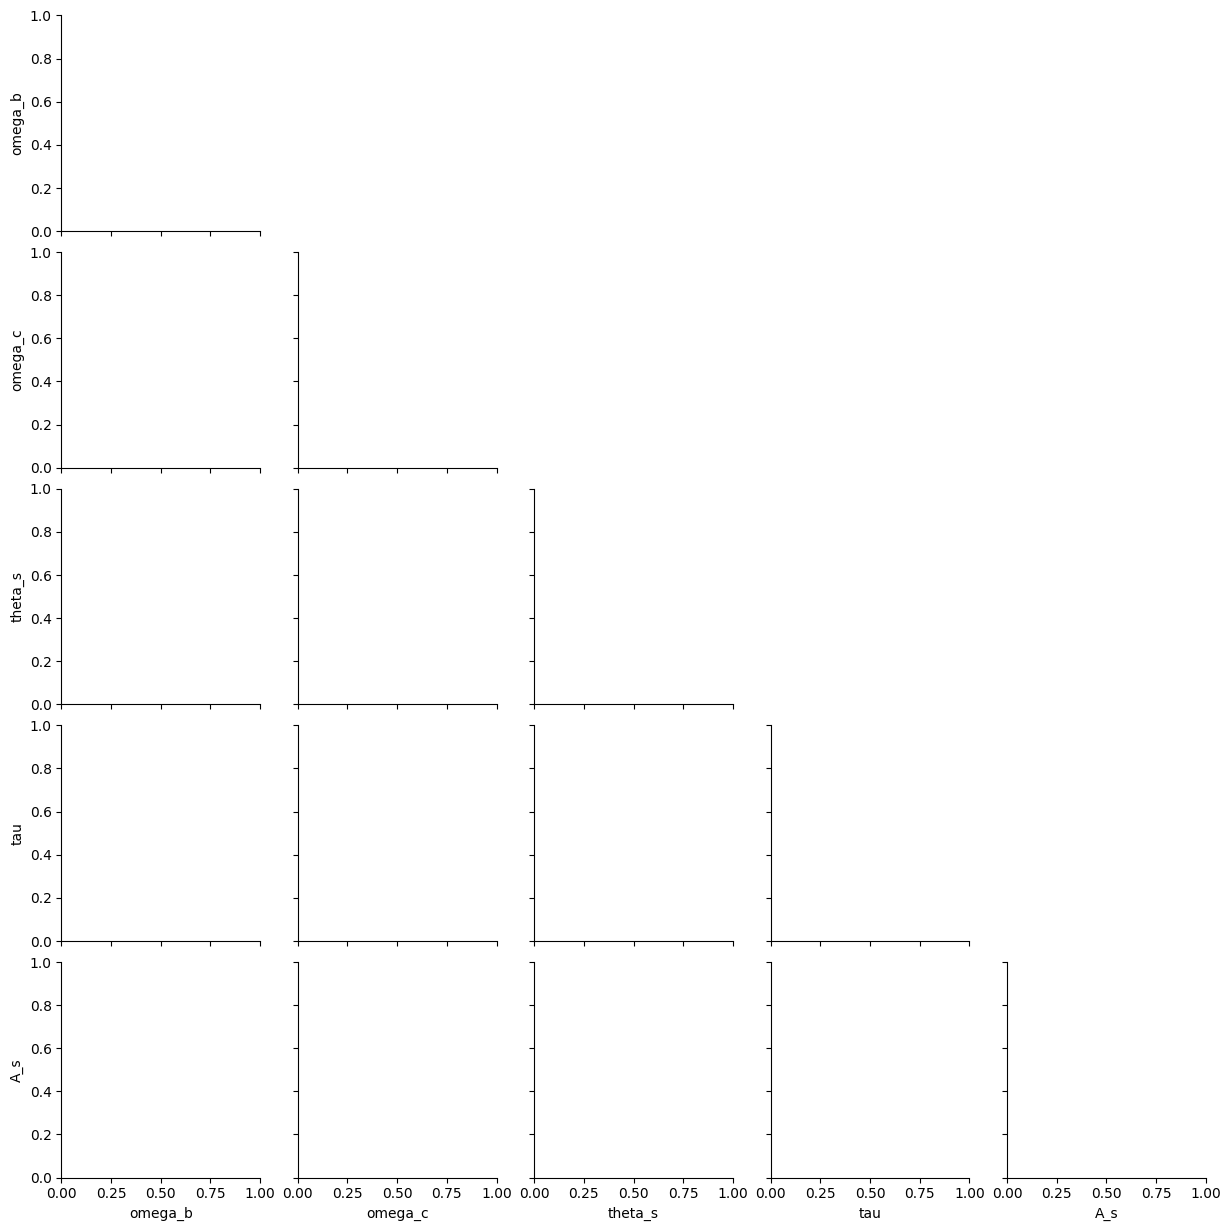

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

# -------------------------
# 1. Simulate Test Data
# -------------------------

np.random.seed(42)
n_samples = 500  # Number of test samples
n_ell = 300  # Number of ell values in each C_ell spectrum

# Simulate five cosmological parameters (you can modify ranges as needed)
params = {
    "omega_b": np.random.uniform(0.02, 0.025, n_samples),
    "omega_c": np.random.uniform(0.1, 0.15, n_samples),
    "theta_s": np.random.uniform(1.03, 1.05, n_samples),
    "tau": np.random.uniform(0.04, 0.1, n_samples),
    "A_s": np.random.uniform(1e-9, 3e-9, n_samples),
}

# Simulate "true" and "predicted" CMB power spectra (C_ell)
Cls_true = np.random.rand(n_samples, n_ell) * 1e3
# Introduce noise to simulate prediction error
Cls_pred = Cls_true + np.random.normal(0, 50, size=(n_samples, n_ell))


def rms(x):
    """Compute root-mean-square of an array."""
    return np.sqrt(np.mean(x**2))


# -------------------------
# 2. Compute a Total Error Metric
# -------------------------
# Here we compute, for each sample, the mean of the relative absolute error:
#   error = mean_{ell} [ |(C_ell_true - C_ell_pred)| / rms(C_ell_true) ]
error_array = np.array(
    [np.mean(np.abs((ct - cp)) / rms(ct)) for ct, cp in zip(Cls_true, Cls_pred)]
)

# -------------------------
# 3. Build a DataFrame
# -------------------------
# Include the simulated parameters and the computed error for each test sample
df = pd.DataFrame(params)
df["error"] = error_array

# -------------------------
# 4. Create a Pairplot with Error Coloring
# -------------------------
# We will use seaborn's PairGrid to create a grid of plots for each pair of parameters.
# In the off-diagonals, we use a custom scatter plot that colors points by the error value.
param_cols = list(params.keys())


# Define a custom scatter plotting function for the lower triangle:
def scatter_with_error(x, y, **kwargs):
    ax = plt.gca()
    # Access the full DataFrame via the "data" keyword (passed when mapping)
    data = kwargs.pop("data", df)
    errors = data["error"].values
    sc = ax.scatter(
        x, y, c=errors, cmap="viridis", s=20, edgecolor="k", linewidth=0.5, **kwargs
    )
    return sc


# Create the PairGrid (only showing the lower triangle and diagonal)
g = sns.PairGrid(df, vars=param_cols, corner=True)

# Map the lower triangle with our custom scatter function.
g.map_lower(scatter_with_error, data=df)
# On the diagonal, show a histogram of each parameter.
g.map_diag(sns.histplot, color="gray", bins=20)

# -------------------------
# 5. Add a Colorbar for the Error Metric
# -------------------------
# We create a ScalarMappable using the same colormap and normalization
norm = mpl.colors.Normalize(vmin=df["error"].min(), vmax=df["error"].max())
sm = mpl.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])  # Required for the colorbar

# Place the colorbar on the figure. Adjust arguments as needed.
g.fig.colorbar(sm, ax=g.axes, orientation="vertical", label="Mean Relative Error")

# Add a suptitle and adjust layout
plt.suptitle(
    "Pairwise Parameter Scatter Plots with Error Coloring", y=1.02, fontsize=16
)
plt.tight_layout()
plt.show()

# -------------------------
# 6. Alternative: 2D Binned Error Heatmaps for Each Parameter Pair
# -------------------------
# If you prefer to see a heatmap (i.e. a binned average error) for each pair,
# you can uncomment and run the following function:


def plot_pairwise_error_heatmap(df, bins=30):
    """Create a grid of heatmaps showing binned mean error for each pair of parameters."""
    param_cols = [col for col in df.columns if col != "error"]
    n = len(param_cols)
    fig, axes = plt.subplots(n, n, figsize=(3.5 * n, 3.5 * n))
    for i in range(n):
        for j in range(n):
            ax = axes[i, j]
            if i < j:
                ax.axis("off")
                continue
            elif i == j:
                sns.histplot(df[param_cols[i]], bins=bins, ax=ax, color="gray")
            else:
                x = df[param_cols[j]]
                y = df[param_cols[i]]
                z = df["error"]
                # Compute a 2D binned statistic (mean error in each bin)
                stat, x_edge, y_edge, _ = binned_statistic_2d(
                    x, y, z, statistic="mean", bins=bins
                )
                pcm = ax.pcolormesh(
                    x_edge, y_edge, stat.T, shading="auto", cmap="viridis"
                )
                fig.colorbar(pcm, ax=ax, orientation="vertical")
            if i == n - 1:
                ax.set_xlabel(param_cols[j])
            else:
                ax.set_xticks([])
            if j == 0:
                ax.set_ylabel(param_cols[i])
            else:
                ax.set_yticks([])
    plt.tight_layout()
    return fig


# Uncomment the following lines to display the binned error heatmap grid:
fig_heat = plot_pairwise_error_heatmap(df, bins=30)
plt.suptitle('2D Binned Mean Error for Parameter Pairs', y=1.02, fontsize=16)
plt.show()